## Figuras 3 e 4 do TCC: escolha do tamanho da janela

Versões das figuras de `00_network_parameters` no padrão de formatação do TCC (sem título, sem grade, sem borda e sem preenchimento; eixos pretos de 1,5 pt; Arial ≈ 10,5 pt quando inseridas com 16 cm de largura).

- **Figura 3:** número médio de arestas das redes com motifs originais e embaralhados em função do tamanho da janela (L<sub>M</sub>), para o registro `sub-010060_EO`. Recalculada com a sincronização atual (atraso nos dois sentidos) e os mesmos parâmetros de `00_network_parameters` (L<sub>M</sub> = 5 a 25 pontos, atraso máximo min(5, L<sub>M</sub> − 1), limiar p99 de um embaralhamento, `random_state = 42`). O resultado é salvo em `data/intermediate/na_vs_window_sub-010060_EO.csv` e reaproveitado nas próximas execuções.
- **Figura 4:** distribuição da frequência alfa individual (IAF) e do período alfa nos registros de olhos fechados (`data/intermediate/iaf_all_ec.csv`, gerado em `00_network_parameters`).

In [1]:
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))

import mne
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Image, display
from plotly.subplots import make_subplots
from tqdm import tqdm

from src.graph.aggregate import edges_per_time
from src.graph.eeg_crop import crop_continuous_segment
from src.graph.motifs import trans_motifs
from src.graph.threshold import estimate_threshold
from src.graph.tvg import build_tvg_parallel

DATA = Path("../../data")
FIG_DIR = Path("../../figures/parametros")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 600 px ≈ 16 cm (largura do texto no TCC): inserida nessa largura, fonte de 14 px ≈ 10,5 pt e linha de 2 px ≈ 1,5 pt
TCC_WIDTH = 600
TCC_FONT = dict(family="Arial", size=14, color="black")
TCC_AXIS = dict(showgrid=False, zeroline=False, showline=True, linecolor="black", linewidth=2, mirror=False,
                ticks="outside", tickcolor="black", tickwidth=2, title_font=TCC_FONT, tickfont=TCC_FONT)


def tcc_style(fig):
    fig.update_xaxes(**TCC_AXIS)
    fig.update_yaxes(**TCC_AXIS)
    fig.update_annotations(font=TCC_FONT)
    fig.update_layout(
        title=None,
        font=TCC_FONT,
        separators=",.",
        template="simple_white",
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="rgba(0,0,0,0)",
    )
    return fig


def save_and_show(fig, name: str, height: int, width: int = TCC_WIDTH):
    tcc_style(fig)
    path = FIG_DIR / f"{name}.png"
    started = time.time()
    try:
        fig.write_image(path, width=width, height=height, scale=4)
    except RuntimeError:
        # o Kaleido às vezes falha ao fechar o navegador depois de já ter gravado o PNG
        if not (path.exists() and path.stat().st_mtime >= started):
            raise
    display(Image(filename=path, width=width))
    print(f"Salvo: {path}")

### Figura 3: número médio de arestas × tamanho da janela

In [2]:
RECORDING = "sub-010060_EO"
NA_CSV = DATA / "intermediate" / f"na_vs_window_{RECORDING}.csv"
WINDOW_SIZES = list(range(5, 26))
MAX_LAG_CAP = 5
N_SHUFFLES = 1
THRESHOLD_PERCENTILE = 99.0
RANDOM_STATE = 42

if NA_CSV.exists():
    df_na = pd.read_csv(NA_CSV)
    print(f"Lido: {NA_CSV}")
else:
    import json

    common = json.loads((DATA / "intermediate" / "tvg_common_continuous_summary.json").read_text(encoding="utf-8"))
    raw = mne.io.read_raw_eeglab(DATA / "preprocessed" / f"{RECORDING}.set", preload=True, verbose=False)
    raw.pick("eeg")
    eeg, sfreq, _, _ = crop_continuous_segment(
        raw, float(common["t0"]), float(common["t1"]), int(common.get("N_SEC_sugerido", 8)), file_name=RECORDING
    )
    motifs = trans_motifs(eeg)
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for L_M in tqdm(WINDOW_SIZES, desc="L_M"):
        max_lag = min(MAX_LAG_CAP, L_M - 1)
        threshold = estimate_threshold(
            eeg, L_M, max_lag, n_shuffles=N_SHUFFLES, percentile=THRESHOLD_PERCENTILE, random_state=RANDOM_STATE
        )["threshold"]
        na_orig = float(np.mean(edges_per_time(build_tvg_parallel(motifs=motifs, window_size=L_M, max_lag=max_lag, threshold=threshold))))
        motifs_shuf = motifs.copy()
        for ch in range(motifs_shuf.shape[0]):
            rng.shuffle(motifs_shuf[ch])
        na_shuf = float(np.mean(edges_per_time(build_tvg_parallel(motifs=motifs_shuf, window_size=L_M, max_lag=max_lag, threshold=threshold))))
        rows.append({"L_M": L_M, "L_M_ms": L_M / sfreq * 1000, "max_lag": max_lag, "threshold": threshold,
                     "Na_original": na_orig, "Na_embaralhado": na_shuf})
    df_na = pd.DataFrame(rows)
    df_na.to_csv(NA_CSV, index=False)
    print(f"Salvo: {NA_CSV}")

df_na.round(3)

Lido: ..\..\data\intermediate\na_vs_window_sub-010060_EO.csv


,L_M,L_M_ms,max_lag,threshold,Na_original,Na_embaralhado
0,5,20.0,4,1.000,1199.894,1229.912
1,6,24.0,5,1.000,1194.906,1233.585
2,7,28.0,5,1.000,904.563,541.627
3,8,32.0,5,1.000,671.478,204.383
4,9,36.0,5,1.000,496.083,73.221
5,10,40.0,5,1.000,366.116,25.136
6,11,44.0,5,0.857,526.284,49.554
7,12,48.0,5,0.857,475.180,45.350
8,13,52.0,5,0.778,574.210,67.102
9,14,56.0,5,0.750,688.575,77.088


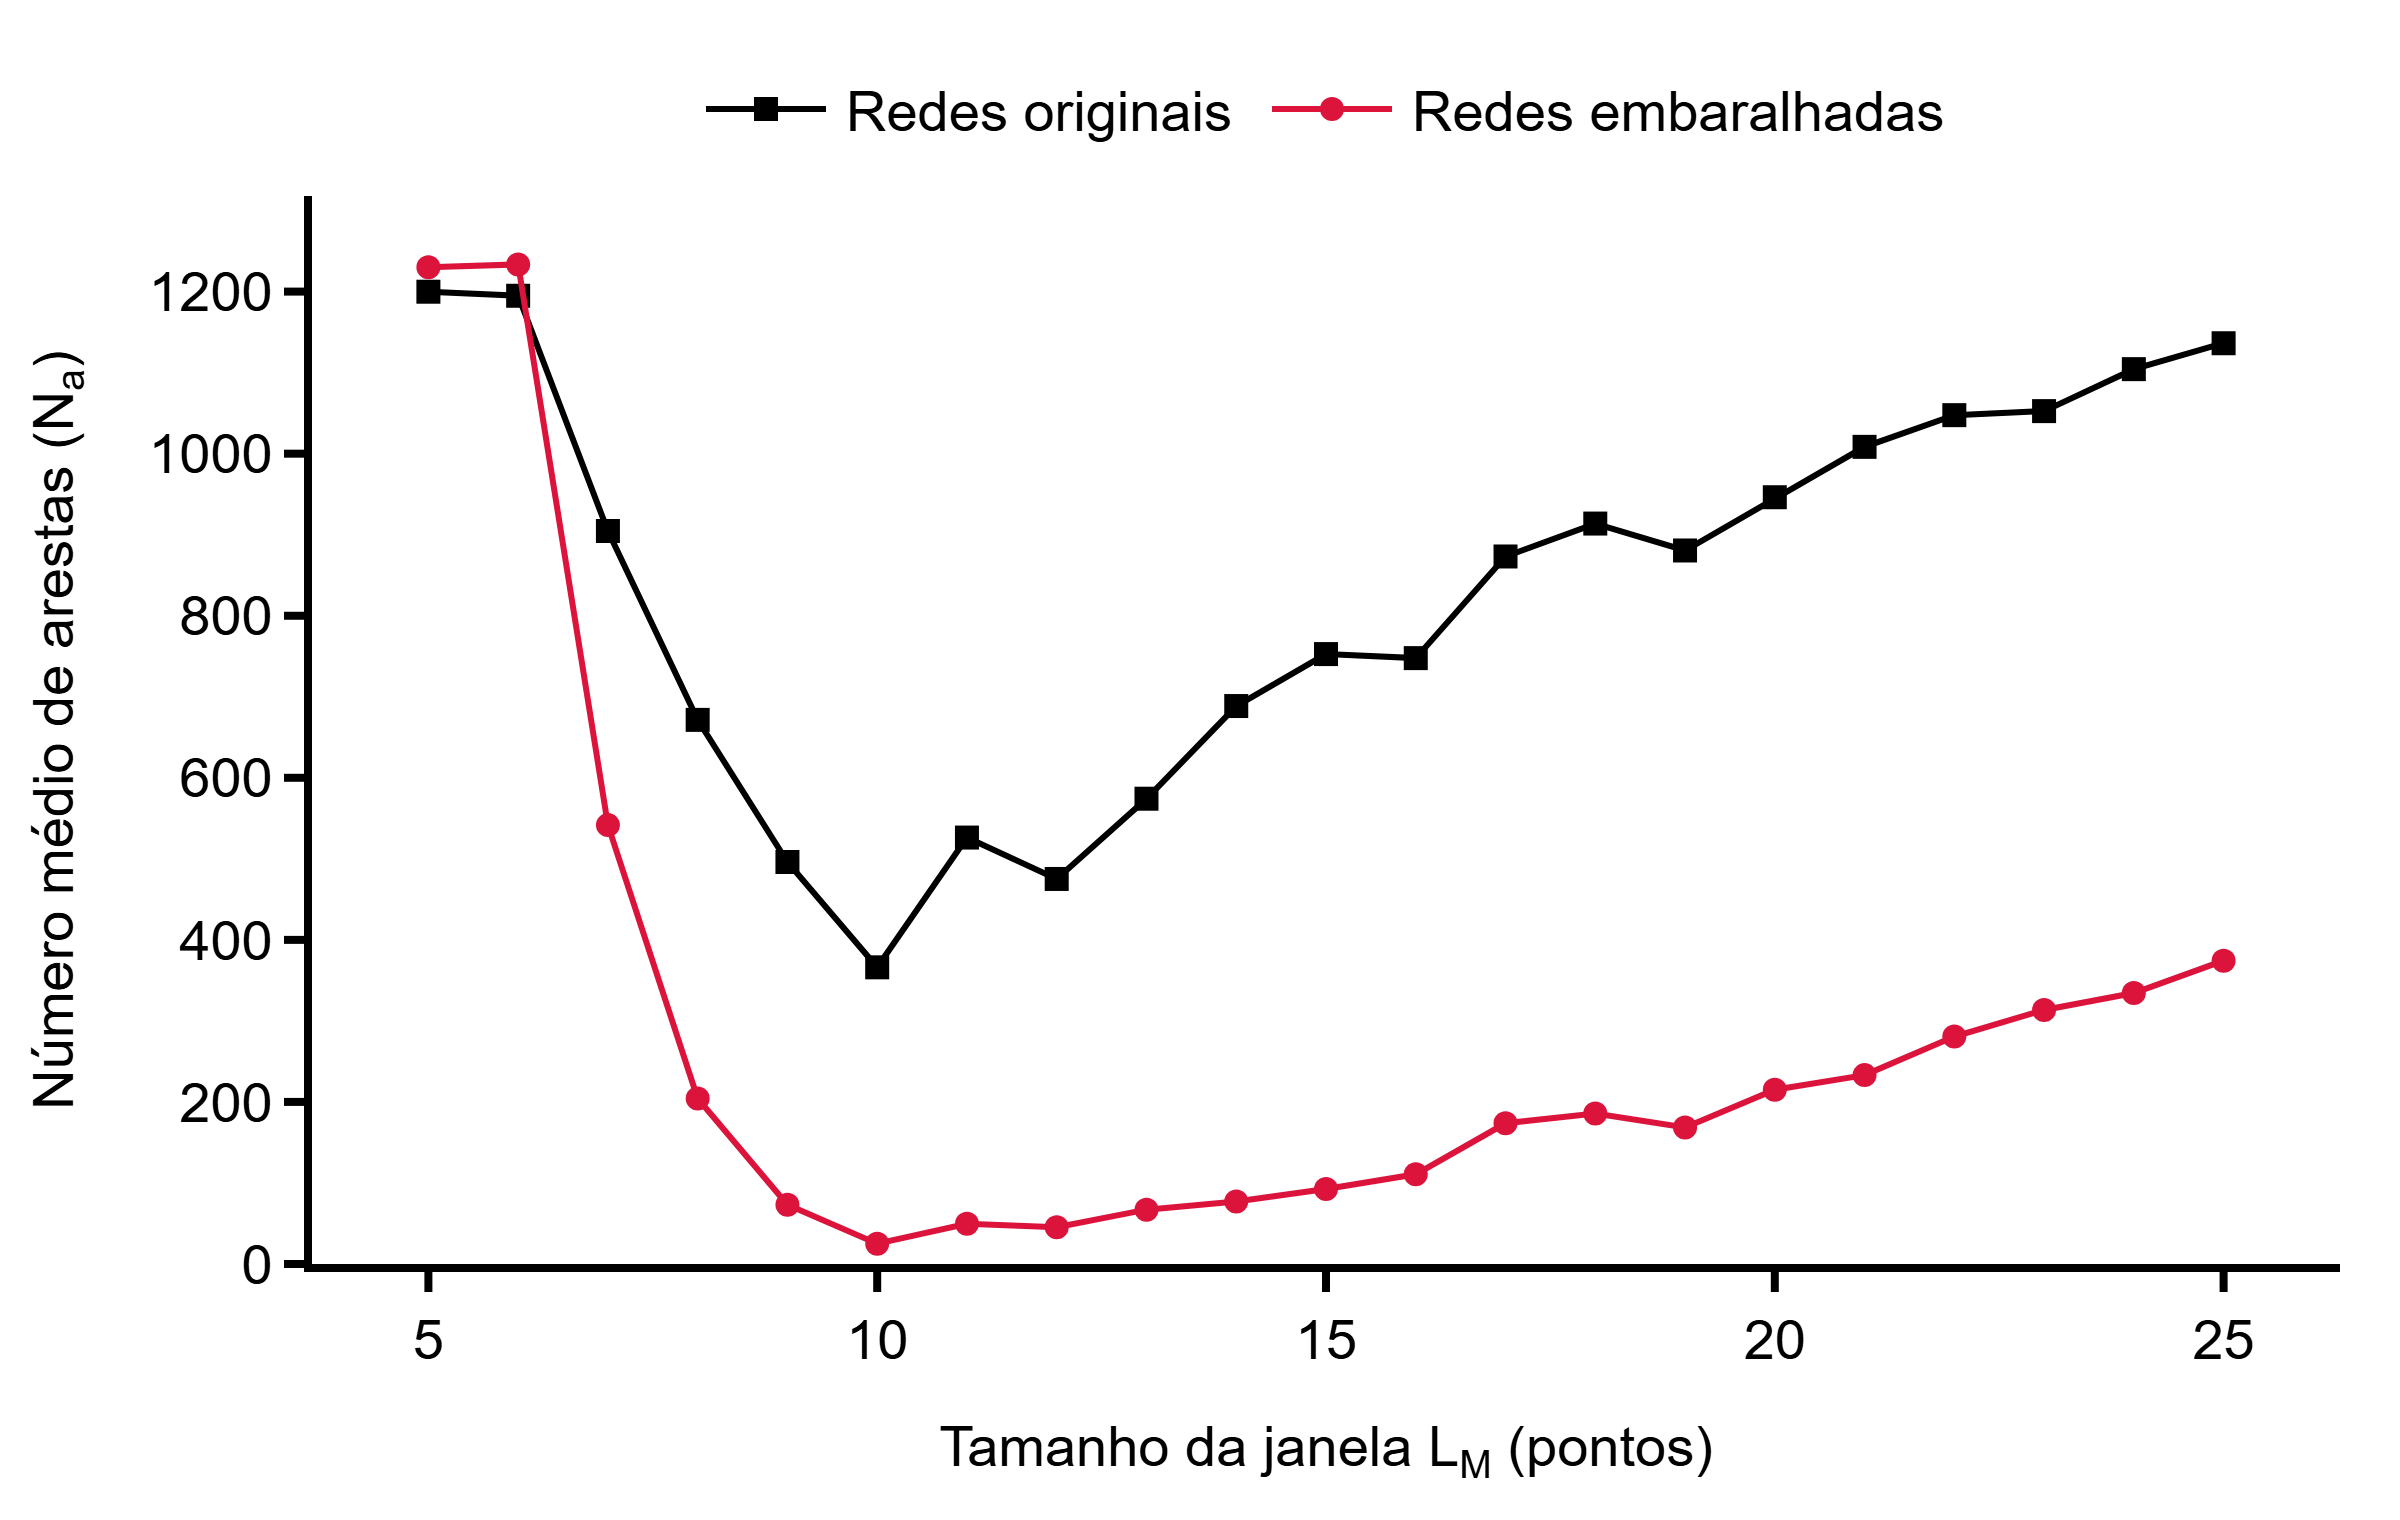

Salvo: ..\..\figures\parametros\fig3_arestas_vs_janela.png


In [3]:
fig3 = go.Figure()
fig3.add_trace(go.Scatter(
    x=df_na["L_M"], y=df_na["Na_original"], mode="lines+markers", name="Redes originais",
    marker=dict(symbol="square", size=6, color="black"), line=dict(color="black", width=1.5),
))
fig3.add_trace(go.Scatter(
    x=df_na["L_M"], y=df_na["Na_embaralhado"], mode="lines+markers", name="Redes embaralhadas",
    marker=dict(symbol="circle", size=6, color="crimson"), line=dict(color="crimson", width=1.5),
))
fig3.update_xaxes(title_text="Tamanho da janela L<sub>M</sub> (pontos)", dtick=5)
fig3.update_yaxes(title_text="Número médio de arestas (N<sub>a</sub>)", rangemode="tozero")
fig3.update_layout(
    showlegend=True,
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.02, yanchor="bottom",
                bgcolor="rgba(0,0,0,0)", borderwidth=0, font=TCC_FONT),
    margin=dict(l=70, r=15, t=40, b=55),
)
save_and_show(fig3, "fig3_arestas_vs_janela", height=380)

### Figura 4: frequência alfa individual (A) e período alfa (B)

Registros EC: 157 | IAF mediana: 9.89 Hz | período mediano: 101 ms


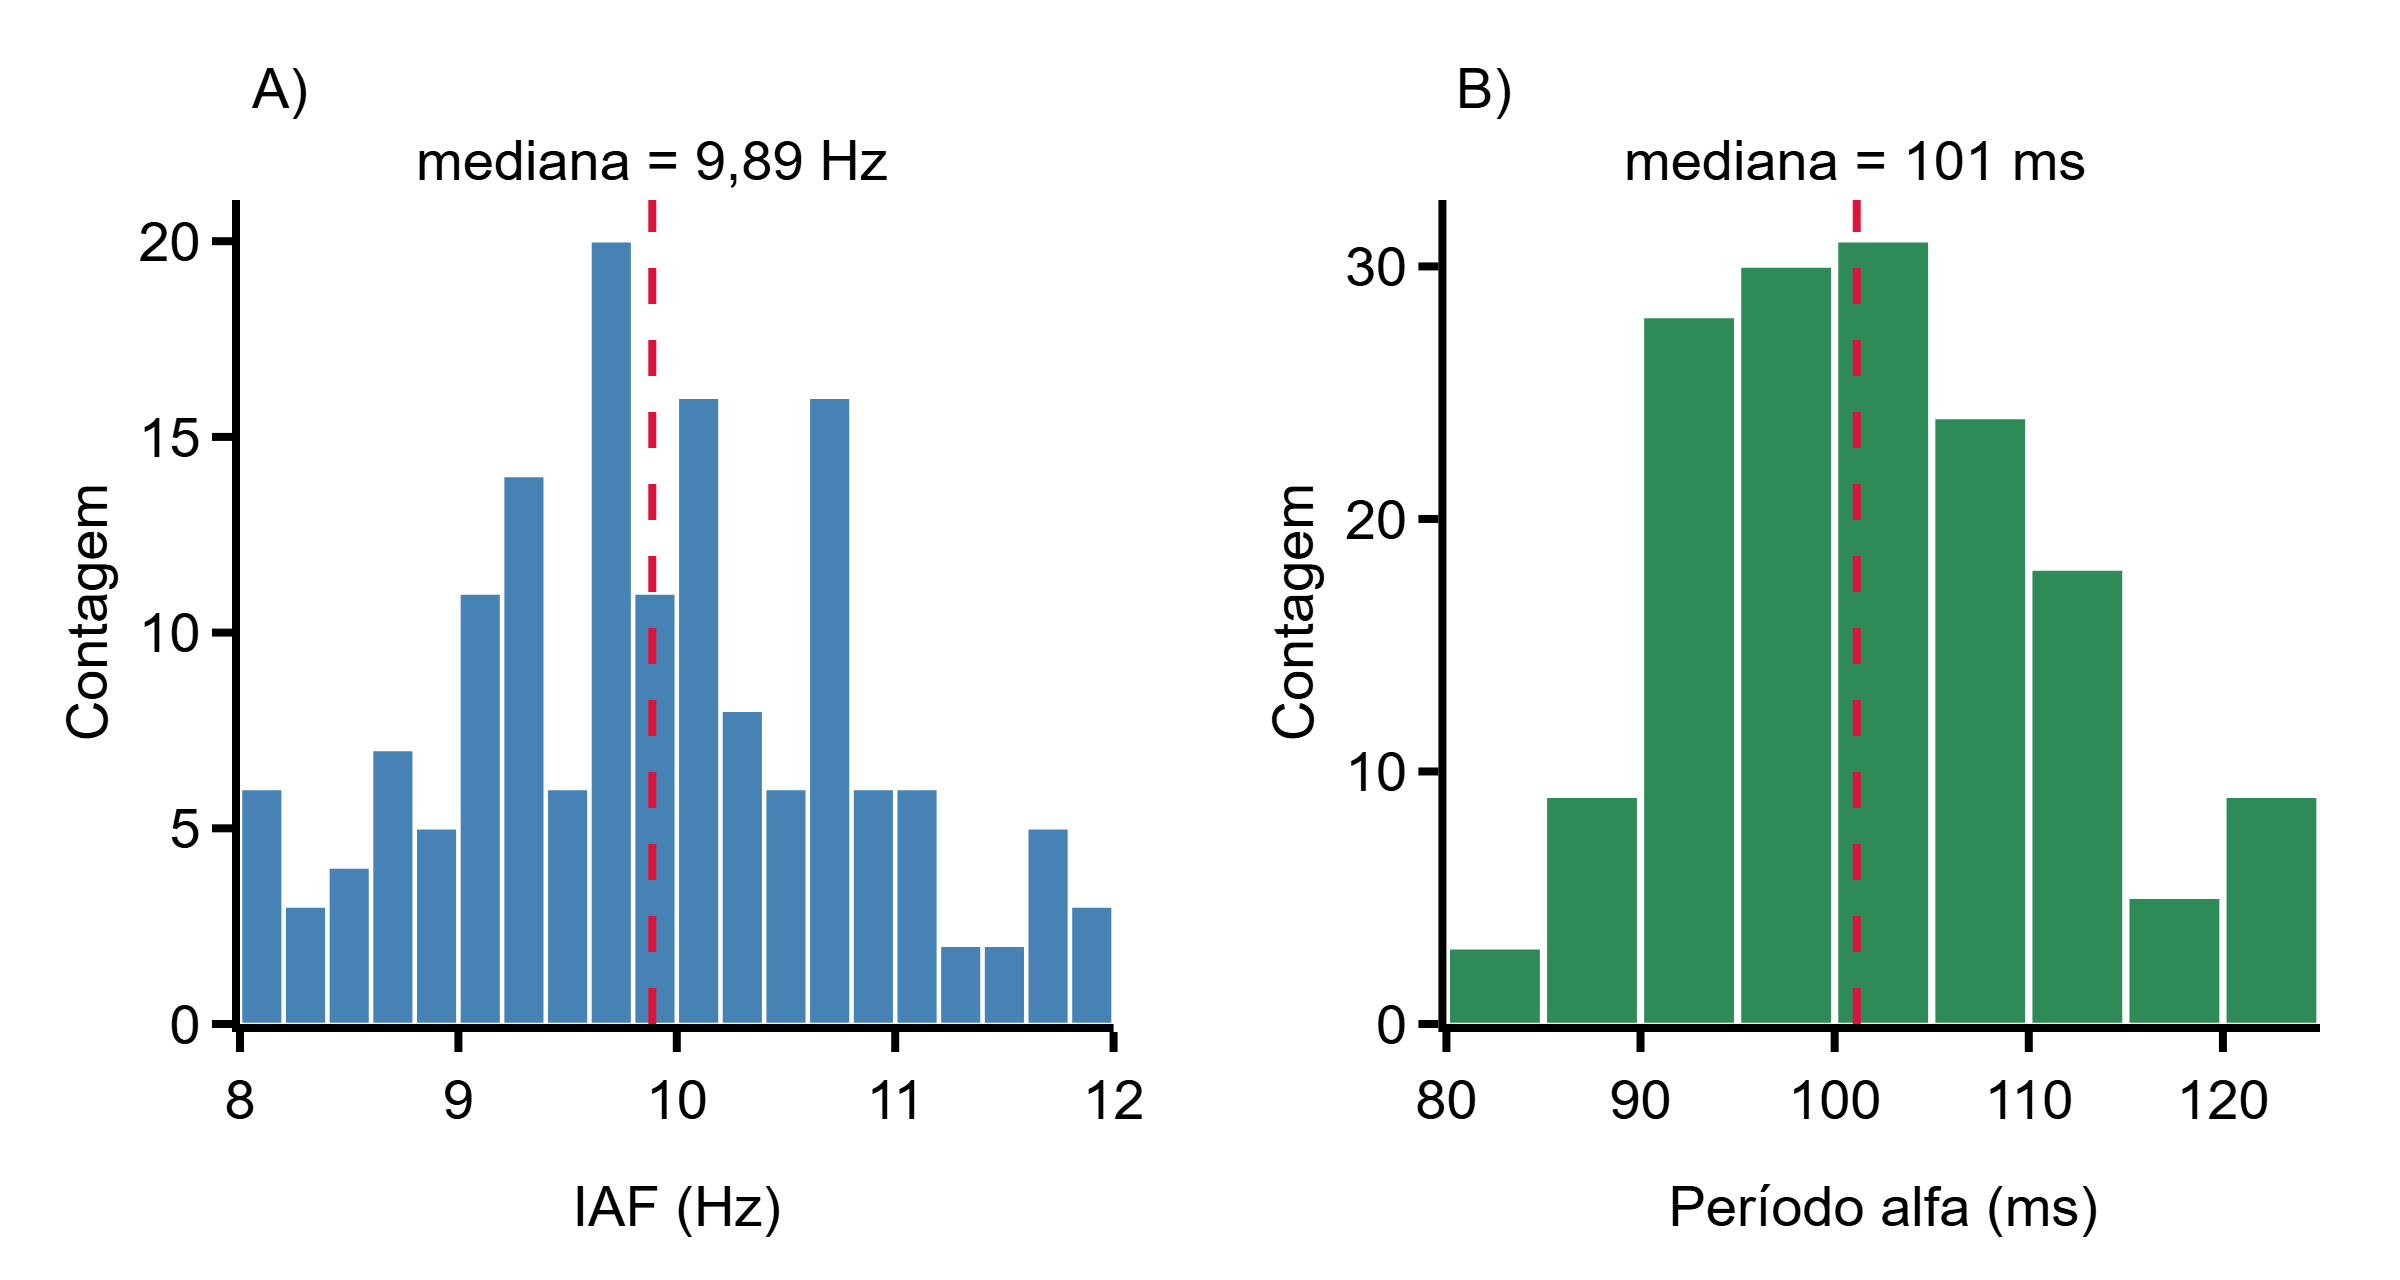

Salvo: ..\..\figures\parametros\fig4_iaf_periodo_alfa.png


In [4]:
df_iaf = pd.read_csv(DATA / "intermediate" / "iaf_all_ec.csv")
iaf_med = float(df_iaf["iaf_hz"].median())
periodo_med = float(df_iaf["periodo_ms"].median())
print(f"Registros EC: {len(df_iaf)} | IAF mediana: {iaf_med:.2f} Hz | período mediano: {periodo_med:.0f} ms")

fig4 = make_subplots(rows=1, cols=2, horizontal_spacing=0.16, subplot_titles=("A)", "B)"))
fig4.add_trace(go.Histogram(x=df_iaf["iaf_hz"], nbinsx=20, marker_color="steelblue", showlegend=False), row=1, col=1)
fig4.add_trace(go.Histogram(x=df_iaf["periodo_ms"], nbinsx=20, marker_color="seagreen", showlegend=False), row=1, col=2)
for col, med, label in ((1, iaf_med, f"mediana = {iaf_med:.2f} Hz"), (2, periodo_med, f"mediana = {periodo_med:.0f} ms")):
    fig4.add_vline(x=med, row=1, col=col, layer="above", opacity=1, line=dict(color="crimson", dash="dash", width=2))
    fig4.add_annotation(x=med, y=1.0, xref=f"x{col}" if col > 1 else "x", yref=f"y{col} domain" if col > 1 else "y domain",
                        text=label.replace(".", ","), showarrow=False, yanchor="bottom", font=TCC_FONT)
for ann, axis in zip(fig4.layout.annotations[:2], ("xaxis", "xaxis2")):
    ann.update(x=fig4.layout[axis].domain[0], xanchor="left", yshift=18)
fig4.update_xaxes(title_text="IAF (Hz)", row=1, col=1)
fig4.update_xaxes(title_text="Período alfa (ms)", row=1, col=2)
fig4.update_yaxes(title_text="Contagem", title_standoff=4)
fig4.update_layout(bargap=0.05, margin=dict(l=60, r=15, t=50, b=55))
save_and_show(fig4, "fig4_iaf_periodo_alfa", height=320)